In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/predictions",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/results",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/models",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/training_history",
    exist_ok=True
)

In [6]:
course_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/course_balanced-new.csv"
)

teacher_test = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/teacher_test.csv"
)

university_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/university_balanced-new.csv"
)

In [7]:
train_df = pd.concat(
    [course_balanced, university_balanced]
).reset_index(drop=True)

test_df = teacher_test.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8436, 5)
Test: (844, 7)


In [8]:
def format_input(row):

    return (
        "[DOMAIN] " + row["domain"] +
        " [ASPECT] " + row["aspect"] +
        " [TEXT] " + row["review"]
    )

train_df["input_text"] = train_df.apply(
    format_input,
    axis=1
)

test_df["input_text"] = test_df.apply(
    format_input,
    axis=1
)

In [9]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_df["label"] = train_df["sentiment"].map(label_map)

test_df["label"] = test_df["sentiment"].map(label_map)

In [10]:
# =====================================================
# TRAIN / VALIDATION SPLIT
# =====================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,
    stratify=train_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# FIXED SHARED TEST SET
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7498, 7)
Validation: (938, 7)
Test: (844, 7)


In [11]:
model_name = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [12]:
train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)

In [13]:
def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/938 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

In [14]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [15]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [16]:
def run_experiment(

    experiment_name,
    learning_rate=2e-5,
    epochs=5,
    use_class_weights=True
):

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    if use_class_weights:

        labels = train_df["label"].values

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(labels),
            y=labels
        )

        class_weights_tensor = torch.tensor(
            class_weights,
            dtype=torch.float
        )

        class WeightedTrainer(Trainer):

            def compute_loss(
                self,
                model,
                inputs,
                return_outputs=False,
                **kwargs
            ):

                labels = inputs.get("labels")

                outputs = model(**inputs)

                logits = outputs.get("logits")

                loss_fct = nn.CrossEntropyLoss(
                    weight=class_weights_tensor.to(model.device)
                )

                loss = loss_fct(logits, labels)

                return (loss, outputs) if return_outputs else loss

        trainer_class = WeightedTrainer

    else:

        trainer_class = Trainer

    training_args = TrainingArguments(

        output_dir=f"./{experiment_name}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=learning_rate,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=epochs,

        weight_decay=0.01,

        logging_steps=100,

        fp16=True,

        report_to="none"
    )

    trainer = trainer_class(

        model=model,

        args=training_args,

        train_dataset=train_dataset,
        eval_dataset=val_dataset,

        compute_metrics=compute_metrics
    )

    trainer.train()

    test_results = trainer.evaluate(
        test_dataset
    )

    print(test_results)

    predictions = trainer.predict(
        test_dataset
    )

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids


    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report_dict = classification_report(

        y_true,
        y_pred,

        target_names=[
            "negative",
            "neutral",
            "positive"
        ],

        output_dict=True
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    report_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_classification_report.csv"
    )

    print(report_df)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    cm_df = pd.DataFrame(

        cm,

        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],

        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    cm_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_confusion_matrix.csv"
    )

    print(cm_df)

    # =====================================================
    # TRAINING HISTORY
    # =====================================================

    history = trainer.state.log_history

    history_df = pd.DataFrame(history)

    history_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_training_history.csv",

        index=False
    )

    print(history_df.head())



    # =====================================================
    # FINAL PREDICTIONS
    # =====================================================

    label_reverse_map = {

        0: "negative",
        1: "neutral",
        2: "positive"
    }

    final_predictions_df = test_df.copy()

    final_predictions_df["true_label"] = y_true

    final_predictions_df["predicted_label"] = y_pred

    final_predictions_df["true_sentiment"] = (

        final_predictions_df["true_label"]
        .map(label_reverse_map)
    )

    final_predictions_df["predicted_sentiment"] = (

        final_predictions_df["predicted_label"]
        .map(label_reverse_map)
    )

    final_predictions_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/predictions/{experiment_name}_predictions.csv",

        index=False
    )

    print(final_predictions_df.head())

    # ERROR ANALYSIS
    errors_df = final_predictions_df[

        final_predictions_df["true_label"]
        != final_predictions_df["predicted_label"]
    ]

    errors_df.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_errors.csv",
        index=False
    )

    print("Total Errors:", len(errors_df))

    # NEUTRAL ERROR
    neutral_errors = errors_df[

        errors_df["true_sentiment"]
        == "neutral"
    ]

    neutral_errors.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_neutral_errors.csv",
        index=False
    )

    print("Neutral Errors:", len(neutral_errors))

    # =====================================================
    # METRICS CSV
    # =====================================================

    metrics_df = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ],

        "Score": [

            test_results["eval_accuracy"],
            test_results["eval_f1_macro"],
            test_results["eval_f1_weighted"]
        ]
    })

    metrics_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_metrics.csv",

        index=False
    )

    print(metrics_df)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    trainer.save_model(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    tokenizer.save_pretrained(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    # =====================================================
    # CLEANUP
    # =====================================================

    trainer.optimizer = None
    trainer.lr_scheduler = None

    del model
    del trainer

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()

    return test_results

In [21]:
gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [22]:
best_metrics = run_experiment(
    "course_university_to_teacher_best"
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.585182,0.460347,0.867804,0.772539,0.874429
2,0.368251,0.481667,0.900853,0.816419,0.898174
3,0.306971,0.625927,0.899787,0.825978,0.902581
4,0.152051,0.689637,0.902985,0.834712,0.906368
5,0.047293,0.895012,0.913646,0.846086,0.914108


{'eval_loss': 2.076340436935425, 'eval_accuracy': 0.8341232227488151, 'eval_f1_macro': 0.7175482336888362, 'eval_f1_weighted': 0.8310889538667525, 'eval_runtime': 3.2797, 'eval_samples_per_second': 257.338, 'eval_steps_per_second': 16.16, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.859155  0.847222  0.853147  288.000000
neutral        0.428571  0.379310  0.402439   87.000000
positive       0.884058  0.910448  0.897059  469.000000
accuracy       0.834123  0.834123  0.834123    0.834123
macro avg      0.723928  0.712327  0.717548  844.000000
weighted avg   0.828608  0.834123  0.831089  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            244            21             23
Actual Neutral              21            33             33
Actual Positive             19            23            427
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.957072  16.224463       0.000019  0.213220

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
epoch4_metrics = run_experiment(
    "course_university_to_teacher_4epoch",
    epochs=4
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.554959,0.541111,0.869936,0.759954,0.867746
2,0.368219,0.537744,0.891258,0.792282,0.887685
3,0.221629,0.829741,0.904051,0.817556,0.901062
4,0.105278,0.812212,0.897655,0.823799,0.899813


{'eval_loss': 1.862927794456482, 'eval_accuracy': 0.8329383886255924, 'eval_f1_macro': 0.7176797930080686, 'eval_f1_weighted': 0.8275266865649404, 'eval_runtime': 3.2183, 'eval_samples_per_second': 262.248, 'eval_steps_per_second': 16.468, 'epoch': 4.0}
              precision    recall  f1-score     support
negative       0.850174  0.847222  0.848696  288.000000
neutral        0.470588  0.367816  0.412903   87.000000
positive       0.873211  0.910448  0.891441  469.000000
accuracy       0.832938  0.832938  0.832938    0.832938
macro avg      0.731324  0.708495  0.717680  844.000000
weighted avg   0.823847  0.832938  0.827527  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            244            16             28
Actual Neutral              21            32             34
Actual Positive             22            20            427
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.951574  12.755329       0.000019  0.21322

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
lr1e5_metrics = run_experiment(
    "course_university_to_teacher_lr1e5",
    learning_rate=1e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.694796,0.587719,0.828358,0.721691,0.837510
2,0.418694,0.602353,0.860341,0.770906,0.862765
3,0.298690,0.539988,0.885928,0.818383,0.891920
4,0.224811,0.627411,0.896588,0.827977,0.899524
5,0.133763,0.809352,0.901919,0.833169,0.903731


{'eval_loss': 1.6460868120193481, 'eval_accuracy': 0.8222748815165877, 'eval_f1_macro': 0.7097769155327182, 'eval_f1_weighted': 0.8214535317909974, 'eval_runtime': 3.1979, 'eval_samples_per_second': 263.925, 'eval_steps_per_second': 16.573, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.844828  0.850694  0.847751  288.000000
neutral        0.404762  0.390805  0.397661   87.000000
positive       0.882979  0.884861  0.883919  469.000000
accuracy       0.822275  0.822275  0.822275    0.822275
macro avg      0.710856  0.708787  0.709777  844.000000
weighted avg   0.820665  0.822275  0.821454  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            245            17             26
Actual Neutral              24            34             29
Actual Positive             21            33            415
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.944285  15.757634       0.000010  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
lr3e5_metrics = run_experiment(
    "course_university_to_teacher_lr3e5",
    learning_rate=3e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.568385,0.481891,0.889126,0.807570,0.891169
2,0.369834,0.448511,0.889126,0.816653,0.892087
3,0.243240,0.523751,0.905117,0.833283,0.905955
4,0.136416,0.859779,0.909382,0.842292,0.911247
5,0.019775,1.085339,0.909382,0.843152,0.911235


{'eval_loss': 2.1017417907714844, 'eval_accuracy': 0.8483412322274881, 'eval_f1_macro': 0.7462624056579922, 'eval_f1_weighted': 0.847563192925012, 'eval_runtime': 3.2941, 'eval_samples_per_second': 256.219, 'eval_steps_per_second': 16.09, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.884477  0.850694  0.867257  288.000000
neutral        0.470588  0.459770  0.465116   87.000000
positive       0.894191  0.918977  0.906414  469.000000
accuracy       0.848341  0.848341  0.848341    0.848341
macro avg      0.749752  0.743147  0.746262  844.000000
weighted avg   0.847211  0.848341  0.847563  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            245            22             21
Actual Neutral              17            40             30
Actual Positive             15            23            431
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.949652  12.646749       0.000029  0.213220

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
no_weights_metrics = run_experiment(
    "course_university_to_teacher_no_weights",
    use_class_weights=False
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.377719,0.324063,0.871002,0.737434,0.862310
2,0.252588,0.307236,0.891258,0.768937,0.881258
3,0.149873,0.466973,0.899787,0.803610,0.896122
4,0.093422,0.548273,0.901919,0.831102,0.906289
5,0.012152,0.643550,0.899787,0.823436,0.903135


{'eval_loss': 1.2434272766113281, 'eval_accuracy': 0.830568720379147, 'eval_f1_macro': 0.7147450769631893, 'eval_f1_weighted': 0.8306127578879264, 'eval_runtime': 3.2407, 'eval_samples_per_second': 260.437, 'eval_steps_per_second': 16.354, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.855172  0.861111  0.858131  288.000000
neutral        0.390805  0.390805  0.390805   87.000000
positive       0.897216  0.893390  0.895299  469.000000
accuracy       0.830569  0.830569  0.830569    0.830569
macro avg      0.714398  0.715102  0.714745  844.000000
weighted avg   0.830668  0.830569  0.830613  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            248            23             17
Actual Neutral              22            34             31
Actual Positive             20            30            419
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.721669   8.669666       0.000019  0.21322

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

             Experiment  Accuracy  Macro_F1  Weighted_F1
0  Weighted Loss (Best)  0.834123  0.717548     0.831089
1              4 Epochs  0.832938  0.717680     0.827527
2             LR = 1e-5  0.822275  0.709777     0.821454
3             LR = 3e-5  0.848341  0.746262     0.847563
4      No Weighted Loss  0.830569  0.714745     0.830613


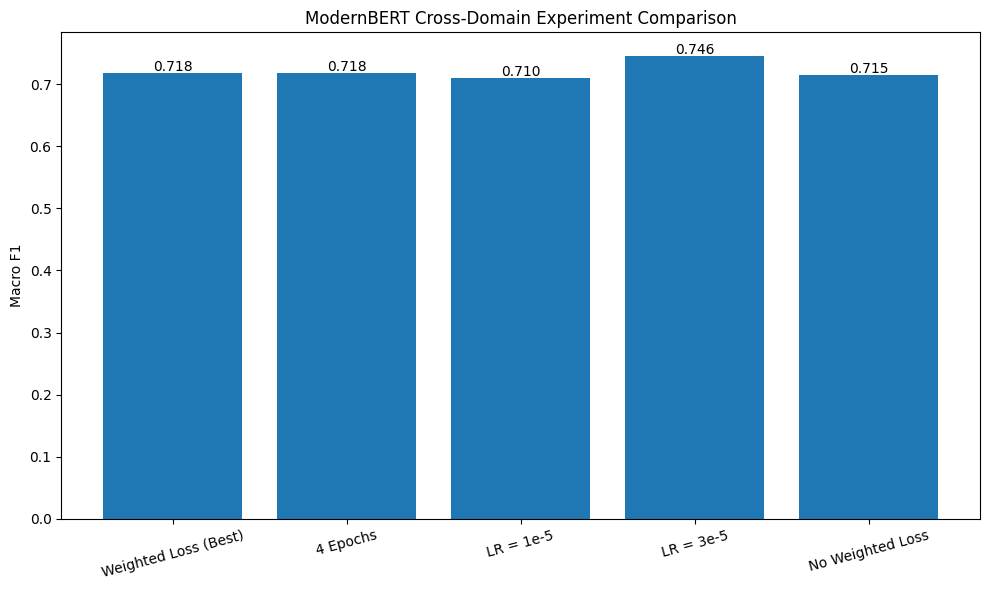

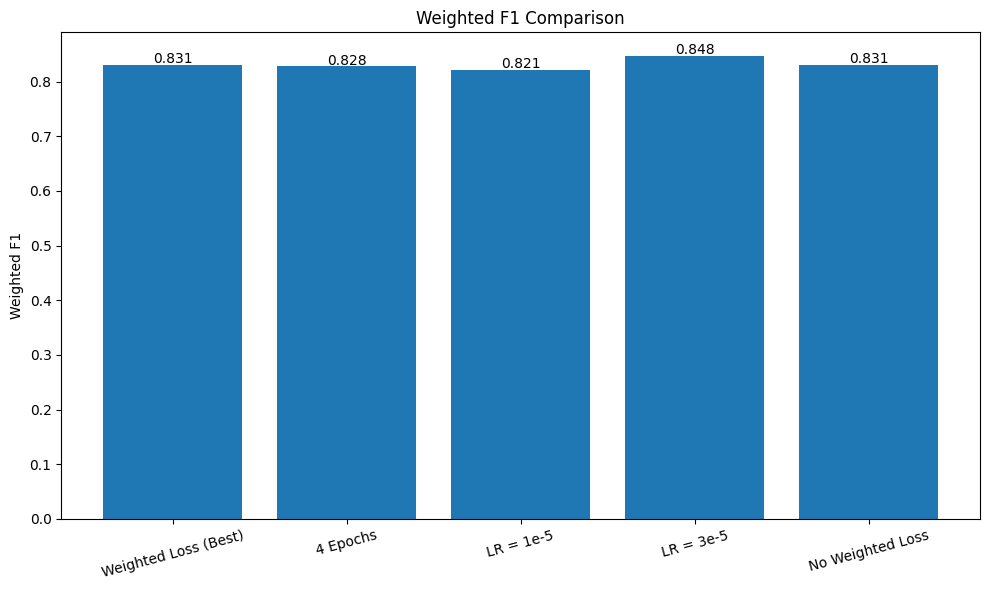

Plots saved successfully


In [28]:
import matplotlib.pyplot as plt

# =====================================================
# FINAL RESULTS TABLE
# =====================================================

final_results_df = pd.DataFrame({

    "Experiment": [

        "Weighted Loss (Best)",
        "4 Epochs",
        "LR = 1e-5",
        "LR = 3e-5",
        "No Weighted Loss"
    ],

    "Accuracy": [

        best_metrics["eval_accuracy"],
        epoch4_metrics["eval_accuracy"],
        lr1e5_metrics["eval_accuracy"],
        lr3e5_metrics["eval_accuracy"],
        no_weights_metrics["eval_accuracy"]
    ],

    "Macro_F1": [

        best_metrics["eval_f1_macro"],
        epoch4_metrics["eval_f1_macro"],
        lr1e5_metrics["eval_f1_macro"],
        lr3e5_metrics["eval_f1_macro"],
        no_weights_metrics["eval_f1_macro"]
    ],

    "Weighted_F1": [

        best_metrics["eval_f1_weighted"],
        epoch4_metrics["eval_f1_weighted"],
        lr1e5_metrics["eval_f1_weighted"],
        lr3e5_metrics["eval_f1_weighted"],
        no_weights_metrics["eval_f1_weighted"]
    ]
})

print(final_results_df)

# =====================================================
# SAVE FINAL RESULTS
# =====================================================

final_results_df.to_csv(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_final_results.csv",

    index=False
)

# =====================================================
# MACRO F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Cross-Domain Experiment Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_macrof1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# WEIGHTED F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Weighted_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Weighted F1")

plt.title("Weighted F1 Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_weightedf1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plots saved successfully")

In [25]:
check_df = pd.read_csv(

    "/content/drive/MyDrive/ABSA_DATASET/predictions/course_university_to_teacher_best_predictions.csv"
)

print(check_df.columns)

print(check_df[["row_id", "true_sentiment", "predicted_sentiment"]].head())

Index(['review', 'aspect', 'sentiment', 'domain', 'row_id', 'input_text',
       'label', 'true_label', 'predicted_label', 'true_sentiment',
       'predicted_sentiment'],
      dtype='object')
         row_id true_sentiment predicted_sentiment
0  teacher_3717       negative            negative
1   teacher_671       positive            positive
2  teacher_2314       positive            positive
3  teacher_1051        neutral            positive
4  teacher_1118       negative            positive
